<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/fabiobento/dnn-course-2026-1/blob/main/C1_M4_Lab_1_cnn_nature_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

# Construindo uma CNN para Classificação da Natureza

Suponha que o pessoal da área de biologia do campus nos procurou com uma ideia: um aplicativo que possa classificar não apenas flores, mas também insetos e pequenos animais. Sua tarefa é projetar e construir o modelo que tornará isso possível.

Este problema é mais complexo do que os que você enfrentou anteriormente. As camadas lineares que você utilizou antes não serão suficientes para capturar os ricos padrões visuais nestas diversas imagens. Para atender a este novo desafio, você construirá uma **Rede Neural Convolucional (CNN)**, um modelo projetado para reconhecer formas, texturas e características em dados visuais.

Neste laboratório, você passará pelo processo de ponta a ponta (*end-to-end*) de construção de uma CNN para esta tarefa de classificação. Você não apenas implementará a arquitetura, mas também seguirá um fluxo de trabalho iterativo — começando com um protótipo menor antes de aumentar a escala (*scaling up*) — e aprenderá a diagnosticar problemas comuns de treinamento.

Você irá:

* **Preparar um Conjunto de Dados Diversificado**: Carregar e transformar um subconjunto especializado de imagens para o seu classificador de natureza multiclasse.
* **Construir uma Arquitetura CNN**: Definir uma CNN completa do zero, combinando camadas convolucionais, de agrupamento (*pooling*) e totalmente conectadas (*fully connected*) para criar um poderoso extrator de características (*feature extractor*).
* **Treinar um Modelo Protótipo**: Seguir um fluxo de trabalho realista treinando primeiro o seu modelo em um subconjunto menor, de 9 classes, para construir um protótipo funcional e estabelecer uma linha de base (*baseline*) de desempenho.
* **Aumentar a Escala e Diagnosticar Desafios**: Treinar o modelo completo em todas as 15 classes e analisar os resultados para identificar desafios comuns de aprendizado de máquina, como o *overfitting* (sobreajuste).

## Importação de bibliotecas

In [1]:
import torch                              # Biblioteca principal do PyTorch para tensores e autograd
import torch.nn as nn                     # Módulo de redes neurais (camadas, funções de perda, etc.)
import torch.optim as optim               # Otimizadores (SGD, Adam, RMSProp, etc.)
import torchvision.transforms as transforms  # Transformações de imagem (normalização, redimensionamento, etc.)
from torch.utils.data import DataLoader  # Carregador de dados com suporte a batches e paralelismo

import helper_utils_7                     # Utilitários auxiliares específicos do projeto

In [2]:
# Configuração do dispositivo
# Define o dispositivo como 'cuda' (GPU) se uma placa de vídeo compatível estiver disponível, caso contrário, usa a 'cpu'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Imprime qual dispositivo está sendo utilizado no momento
print(f"Usando o dispositivo: {device}")

Usando o dispositivo: cuda


## Baixar os arquivos auxiliares

In [ ]:
import os

def download_files(filenames):
    """
    Baixa uma lista de arquivos do repositório do curso se eles não existirem localmente.
    """
    # URL base do repositório remoto onde os arquivos do curso estão hospedados
    base_url = "https://raw.githubusercontent.com/fabiobento/dnn-course-2026-1/main/"
    
    # Itera sobre cada nome de arquivo presente na lista fornecida
    for filename in filenames:
        # Verifica se o arquivo já existe no diretório local para evitar downloads duplicados
        if not os.path.exists(filename):
            # Monta a URL completa combinando o endereço base com o nome do arquivo
            url = f"{base_url}{filename}"
            print(f"Baixando {filename}...")
            
            # Executa uma chamada de sistema utilizando o comando 'wget'
            # A flag '-q' ativa o modo silencioso (quiet) e '-O' define o nome do arquivo de saída
            os.system(f"wget -q {url} -O {filename}")
        else:
            # Caso o arquivo já esteja presente, o script apenas notifica o usuário e pula para o próximo
            print(f"O arquivo '{filename}' já existe localmente. Pulando...")

# Lista com os arquivos auxiliares essenciais para a execução correta deste notebook:
arquivos_necessários = [
    'helper_utils_7.py',           # Script local com funções utilitárias de suporte
]

# Dispara a função para garantir que todos os dependências estejam disponíveis no ambiente local
download_files(arquivos_necessários)

## Preparando o Conjunto de Dados da Natureza

Para este laboratório, você trabalhará com uma coleção de imagens retiradas do conhecido [conjunto de dados CIFAR-100](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR100.html). Este conjunto de dados é um recurso fantástico para tarefas de visão computacional, contendo milhares de pequenas **imagens coloridas de 32x32**, que são perfeitas para treinar uma CNN. É uma coleção diversificada, o que é exatamente o que você precisa para o aplicativo expandido de classificação da natureza.

Embora o CIFAR-100 tenha 100 classes diferentes, você não precisará de todas elas. Para atender aos novos requisitos do seu aplicativo, você se concentrará em uma seleção curada de **15 classes** que se encaixam no tema de um classificador de natureza. Esta seleção incluirá flores, insetos e mamíferos. Especificamente, você trabalhará com:

* **Flores** (*Flowers*): 'orchid', 'poppy', 'rose', 'sunflower', 'tulip'
* **Mamíferos** (*Mammals*): 'fox', 'porcupine', 'possum', 'raccoon', 'skunk'
* **Insetos** (*Insects*): 'bee', 'beetle', 'butterfly', 'caterpillar', 'cockroach'

### Transformações de Imagem

Antes de carregar o conjunto de dados, primeiro você precisa definir os pipelines de transformação para ele. Como todas as imagens no conjunto de dados já possuem um tamanho padrão de **32x32**, você não precisa adicionar uma etapa de redimensionamento. Seu pipeline de treinamento incluirá aumento de dados (*data augmentation*), enquanto ambos os pipelines converterão as imagens em **tensores** e as **normalizarão** usando os valores padrão de média e desvio padrão para o conjunto de dados CIFAR-100.

* Defina a média e o desvio padrão específicos para o conjunto de dados CIFAR-100.

In [3]:
# =============================================================================
# Estatísticas de normalização do dataset CIFAR-100
# Valores pré-calculados sobre o conjunto de treinamento completo
# Utilizados para normalizar as imagens antes de alimentar a rede neural
# =============================================================================

# Média por canal (R, G, B) do dataset CIFAR-100
# Usada para centralizar os valores de pixel em torno de zero
cifar100_mean = (0.5071, 0.4867, 0.4408)

# Desvio padrão por canal (R, G, B) do dataset CIFAR-100
# Usada para escalar os valores de pixel para variância unitária
cifar100_std = (0.2675, 0.2565, 0.2761)

* Defina dois pipelines separados utilizando `transforms.Compose`.
    * Um para o conjunto de treinamento, que inclui aumento de dados (*data augmentation*), e outro para o conjunto de validação.

In [4]:
# =============================================================================
# Pipelines de transformação de imagens para treinamento e validação
# Aplicadas automaticamente pelo DataLoader a cada batch carregado
# =============================================================================

# Pipeline de transformação do conjunto de TREINAMENTO
# Inclui augmentação de dados para aumentar a diversidade dos exemplos
# e reduzir o overfitting durante o treinamento
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),          # Espelhamento horizontal aleatório (p=0.5 por padrão)
    transforms.RandomRotation(15),              # Rotação aleatória de até ±15 graus
    transforms.ToTensor(),                      # Converte PIL Image ou ndarray para tensor [C, H, W] no intervalo [0.0, 1.0]
    transforms.Normalize(cifar100_mean, cifar100_std)  # Normaliza cada canal com média e desvio padrão do CIFAR-100
])

# Pipeline de transformação do conjunto de VALIDAÇÃO
# Sem augmentação: apenas conversão e normalização para avaliação reprodutível
val_transform = transforms.Compose([
    transforms.ToTensor(),                      # Converte PIL Image ou ndarray para tensor [C, H, W] no intervalo [0.0, 1.0]
    transforms.Normalize(cifar100_mean, cifar100_std)  # Normaliza cada canal com média e desvio padrão do CIFAR-100
])

### Preparando o Pipeline de Dados

Com suas transformações prontas, é hora de carregar os dados. Para mostrar rapidamente um protótipo funcional ao borboletário vizinho, uma estratégia inteligente é começar com um conjunto de dados menor e mais gerenciável. Isso permite que você teste todo o seu pipeline e construa um modelo de linha de base (*baseline*) sem os longos tempos de espera exigidos para o conjunto de dados completo.

Portanto, em vez de usar todas as 15 classes de uma vez, você começará com um subconjunto balanceado de **9 classes** (**3 de cada categoria**). Essa abordagem iterativa é uma prática comum e eficiente no aprendizado de máquina do mundo real.

Para este protótipo inicial, você usará as seguintes classes:

* **Flores** (*Flowers*): 'orchid', 'poppy', 'sunflower'
* **Mamíferos** (*Mammals*): 'fox', 'raccoon', 'skunk'
* **Insetos** (*Insects*): 'butterfly', 'caterpillar', 'cockroach'

* Crie uma lista em Python contendo os nomes das 9 classes que você usará para o protótipo inicial.

In [5]:
# =============================================================================
# Subconjunto de classes selecionadas do dataset CIFAR-100
# O CIFAR-100 possui 100 classes no total; aqui filtramos apenas 9
# organizadas em 3 superclasses biológicas para o experimento
# =============================================================================

subset_target_classes = [
    # Flores
    'orchid', 'poppy', 'sunflower',
    # Mamíferos
    'fox', 'raccoon', 'skunk',
    # Insetos
    'butterfly', 'caterpillar', 'cockroach'
]

* Use a função auxiliar `load_cifar100_subset`, passando a sua lista `subset_target_classes` e ambos os pipelines de transformação.
* Esta função lida com todo o processo de carregamento: ela faz o download do conjunto de dados CIFAR-100 completo, aplica as transformações especificadas e, em seguida, filtra o resultado para incluir apenas as **9 classes** que você selecionou.
* Ela retorna os objetos finais dos conjuntos de dados de treinamento e validação, prontos para a próxima etapa.

In [6]:
# Chama a função auxiliar para preparar os datasets (conjuntos de dados) de treino e validação
# Passa a lista de classes desejadas (subset_target_classes) e as transformações correspondentes
train_dataset_proto, val_dataset_proto = helper_utils_7.load_cifar100_subset(subset_target_classes, train_transform, val_transform)

Dataset encontrado em './cifar_100'. Carregando dos arquivos locais.


/home/fabio/Documentos/vscode/dnn-course-2026-1/venv_dl/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Dataset carregado com sucesso.

Filtrando para 9 classes...
Filtragem concluída. Retornando os datasets de treino e validação.


* Com seus objetos `Dataset` prontos, a etapa final no pipeline de dados é criar os `DataLoaders`.

In [7]:
# Define o número de amostras a serem processadas em cada lote (batch)
batch_size = 64

# Cria um carregador de dados (DataLoader) para o conjunto de treino, com o embaralhamento (shuffle) ativado
train_loader_proto = DataLoader(train_dataset_proto, batch_size=batch_size, shuffle=True)

# Cria um carregador de dados (DataLoader) para o conjunto de validação, sem embaralhamento
val_loader_proto = DataLoader(val_dataset_proto, batch_size=batch_size, shuffle=False)

### Visualizando as Imagens de Treinamento

Com o seu pipeline de dados concluído, é sempre uma boa ideia analisar alguns exemplos do seu conjunto de treinamento. Isso ajuda a confirmar se os seus dados foram carregados e processados corretamente. A função auxiliar a seguir exibirá uma amostra aleatória das suas imagens de treinamento.

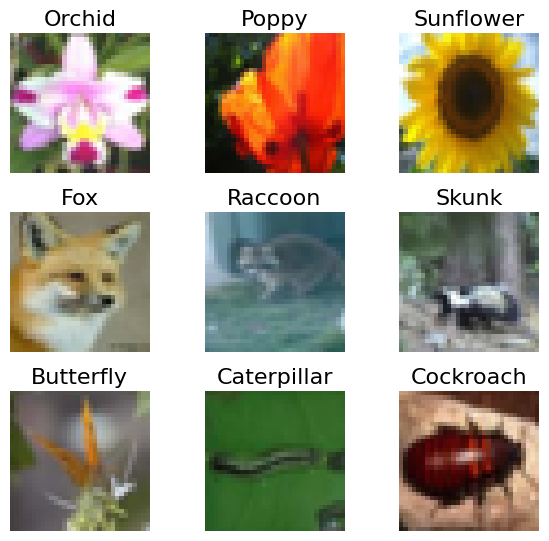

In [8]:
# Visualiza uma grade de 3x3 com imagens aleatórias do conjunto de treino
# A função seleciona amostras aleatórias do dataset para exibição e verificação visual
helper_utils_7.visualise_images(train_dataset_proto, grid=(3, 3))

## Construindo a Arquitetura da CNN

Com seus dados prontos, é hora de construir o núcleo do seu classificador de natureza. Para uma tarefa complexa como a identificação de diferentes espécies em imagens, as camadas lineares que você usou antes não são suficientes, pois elas analisam os pixels individualmente sem entender suas relações espaciais.

Agora você construirá uma **Rede Neural Convolucional (CNN)**, uma arquitetura projetada especificamente para "ver" e reconhecer padrões, bordas e texturas em imagens através de uma série de filtros aprendíveis (*learnable filters*). Você definirá a estrutura do seu modelo usando o `nn.Module` do PyTorch, combinando vários tipos de camadas para criar um poderoso classificador de imagens.

Aqui está um detalhamento das principais camadas que você usará:

**Camada Convolucional ([nn.Conv2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html))**

> Este é o bloco de construção central de uma CNN, que usa filtros aprendíveis para varrer a imagem em busca de características visuais. A saída é um conjunto de "mapas de características" (*feature maps*) que destacam onde esses padrões aparecem na imagem.
> * `in_channels`: O número de canais da camada anterior; para a primeira camada, este valor é 3, correspondente aos canais de cores RGB.
> * `out_channels`: O número de filtros que a camada irá aprender, determinando o número de mapas de características de saída.
> * `kernel_size`: As dimensões do filtro, como uma grade 3x3 que examina um pixel e seus vizinhos imediatos.
> * `padding`: Adiciona uma borda ao redor da imagem, permitindo que o *kernel* processe os pixels da extremidade enquanto preserva as dimensões originais da imagem.
> 
> 

**Função de Ativação ReLU ([nn.ReLU](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html))**

> Uma função de ativação que introduz não-linearidade mudando todos os valores negativos nos mapas de características para zero. Isso ajuda o modelo a aprender padrões mais complexos.

**Camada de Agrupamento Máximo (*Max Pooling*) ([nn.MaxPool2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html))**

> Esta camada reduz a resolução (*downsamples*) dos mapas de características diminuindo sua altura e largura, o que torna a rede mais eficiente. Ela desliza uma janela sobre o mapa de características e mantém apenas o maior valor único daquela janela, descartando o resto.
> * `kernel_size`: O tamanho da janela na qual o agrupamento (*pooling*) será realizado, como uma área 2x2.
> * `stride`: O tamanho do passo que a janela se move através da imagem. Um *stride* de 2 com um *kernel* 2x2 reduzirá pela metade as dimensões do mapa de características.
> 
> 

**Camada de Achatamento (*Flatten*) ([nn.Flatten](https://docs.pytorch.org/docs/stable/generated/torch.nn.Flatten.html))**

> Uma camada utilitária que desenrola (*unrolls*) os mapas de características 2D em um único vetor 1D. Esta é uma etapa necessária para preparar os dados para as camadas lineares totalmente conectadas.

**Camada Linear ([nn.Linear](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html))**

> Também conhecida como camada totalmente conectada (*fully connected layer*), ela realiza a classificação final. Ela combina as características aprendidas pelas camadas convolucionais em uma previsão final.

**Camada de Abandono (*Dropout*) ([nn.Dropout](https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html))**

> Uma técnica de regularização que ajuda a evitar o *overfitting* (sobreajuste), definindo aleatoriamente uma fração das ativações dos neurônios como zero durante o treinamento. Isso força a rede a aprender características mais robustas em vez de depender muito de qualquer padrão único.

In [9]:
class SimpleCNN(nn.Module):
    """
    Um modelo simples de Rede Neural Convolucional (CNN).

    A arquitetura consiste em três blocos convolucionais seguidos por duas
    camadas totalmente conectadas (fully connected) para classificação.
    """
    def __init__(self, num_classes):
        """
        Inicializa as camadas da rede neural.

        Args:
            num_classes: O número de classes de saída para a camada final.
        """
        # Chama o construtor da classe pai (nn.Module)
        super(SimpleCNN, self).__init__()
        
        # Define o primeiro bloco convolucional
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Define o segundo bloco convolucional
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Define o terceiro bloco convolucional
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Define a camada para achatar (flatten) os mapas de características
        self.flatten = nn.Flatten()

        # Define as camadas totalmente conectadas (densas)
        # A imagem de entrada é 32x32. Após 3 camadas de pooling: 4x4
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)


    def forward(self, x):
        """
        Define o fluxo de propagação para frente (forward pass) do modelo.

        Args:
            x: O tensor de entrada no formato (batch_size, canais, altura, largura).

        Returns:
            O tensor de saída contendo os logits para cada classe.
        """
        # Passa a entrada pelo primeiro bloco convolucional
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        # Passa os mapas de características pelo segundo bloco convolucional
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        # Passa os mapas de características pelo terceiro bloco convolucional
        x = self.conv3(x)
        x = self.relu3(x)
        x = self.pool3(x)

        # Achata a saída para as camadas totalmente conectadas
        x = self.flatten(x)

        # Passa as características achatadas pelas camadas totalmente conectadas
        x = self.fc1(x)
        x = self.relu4(x)
        x = self.dropout(x)
        x = self.fc2(x)

        # Retorna os logits de saída finais
        return x

Com a arquitetura `SimpleCNN` definida, o próximo passo é criar uma instância do modelo para o seu protótipo.

* Primeiro, determine dinamicamente o número de classes de saída verificando o comprimento da lista de classes no seu `train_dataset_proto`.
* Crie uma instância da sua `SimpleCNN`, passando `num_classes` para o seu construtor.

In [10]:
# Obtém o número total de classes do conjunto de treinamento
num_classes = len(train_dataset_proto.classes)

# Instancia o modelo de rede neural convolucional criado (SimpleCNN)
# Passa o número de classes como argumento para configurar a camada de saída final
prototype_model = SimpleCNN(num_classes)

Antes de começar o treinamento, é muito útil visualizar como o formato dos seus dados muda à medida que eles passam pela CNN. Isso confirmará que a sua arquitetura está configurada corretamente e mostrará como as dimensões espaciais encolhem enquanto o número de canais aumenta a cada bloco convolucional.

* Defina a função auxiliar `print_data_flow`.
* Esta função passará uma imagem colorida de amostra de 32x32 pelo seu modelo, camada por camada, imprimindo o formato (*shape*) do tensor em cada etapa principal para rastrear a sua jornada, desde a entrada até a previsão final.

In [11]:
def print_data_flow(model):
    """
    Imprime o formato (shape) de um tensor conforme ele passa por cada camada do modelo.

    Args:
        model: Uma instância do modelo PyTorch a ser inspecionado.
    """
    # Cria um tensor de entrada de amostra (batch_size, canais, altura, largura)
    x = torch.randn(1, 3, 32, 32)

    # Acompanha o formato do tensor em cada estágio
    print(f"Formato de entrada: \t\t{x.shape}")

    # Primeiro bloco convolucional
    x = model.conv1(x)
    print(f"Depois da conv1: \t\t{x.shape}")
    x = model.relu1(x)
    x = model.pool1(x)
    print(f"Depois da pool1: \t\t{x.shape}")

    # Segundo bloco convolucional
    x = model.conv2(x)
    print(f"Depois da conv2: \t\t{x.shape}")
    x = model.relu2(x)
    x = model.pool2(x)
    print(f"Depois da pool2: \t\t{x.shape}")

    # Terceiro bloco convolucional
    x = model.conv3(x)
    print(f"Depois da conv3: \t\t{x.shape}")
    x = model.relu3(x)
    x = model.pool3(x)
    print(f"Depois da pool3: \t\t{x.shape}")

    # Achata o tensor usando a camada de flatten do modelo
    x = model.flatten(x)
    print(f"Depois do flatten: \t\t{x.shape}")

    # Camadas totalmente conectadas (fully connected)
    x = model.fc1(x)
    print(f"Depois da fc1: \t\t{x.shape}")
    x = model.relu4(x)
    x = model.dropout(x)
    x = model.fc2(x)
    print(f"Formato de saída (fc2): \t{x.shape}")

Você agora pode imprimir um resumo do seu modelo e rastrear o fluxo de dados para vê-lo em ação.

* Chame a sua função auxiliar para imprimir o formato (*shape*) do tensor em cada etapa.
* O tensor começa como uma imagem `(1, 3, 32, 32)`. À medida que passa pelos blocos `conv` e `pool`, o número de **canais aumenta** enquanto o **tamanho espacial é reduzido pela metade** a cada etapa.
* O mapa de características final `(1, 128, 4, 4)` é **achatado** (*flattened*) em um vetor 1D para ser processado pelas camadas lineares. O **formato de saída** final do modelo **é** `(1, 9)`, fornecendo uma pontuação para cada uma das 9 classes.

In [12]:
# Imprime a arquitetura estrutural do modelo (camadas, configurações, etc.)
print(prototype_model)

# Chama a função auxiliar para visualizar o fluxo e a transformação dos dados através das camadas
print("\n--- Rastreando o Fluxo de Dados ---")
print_data_flow(prototype_model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=9, bias=True)
)

--- Rastreando o Fluxo de Dados ---
Formato de entrada: 		torch.Size([1, 3, 32, 32])
Depois da conv1: 		torch.Size([1, 32, 32, 32])
Depois da pool1: 		torch.Size([1, 32, 16, 16])
Depois da conv2: 		torch.Size([1, 

## Treinando o Modelo

Com o seu modelo definido e o pipeline de dados preparado, você está pronto para configurar o processo de treinamento. Isso envolve inicializar uma função de perda para medir o erro do seu modelo e um otimizador para atualizar os seus pesos com base nesse erro.

### Inicializar a Função de Perda e o Otimizador

Antes de iniciar o loop de treinamento, você definirá dois componentes principais:

* Você usará [nn.CrossEntropyLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html). Esta é a função de perda padrão para tarefas de classificação multiclasse, pois é projetada para medir o erro quando um modelo precisa escolher uma classe entre várias possibilidades.
* Você usará o otimizador [Adam](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html). Este é um algoritmo popular e eficiente que atualiza os pesos do modelo para minimizar a perda.

In [13]:
# Função de perda (Loss function)
# Utiliza a Entropia Cruzada, ideal para problemas de classificação multiclasse
loss_function = nn.CrossEntropyLoss()

# Otimizador para o modelo de protótipo
# Utiliza o algoritmo Adam para atualizar os parâmetros do modelo com uma taxa de aprendizado (learning rate) de 0.001
optimizer_prototype = optim.Adam(prototype_model.parameters(), lr=0.001)

### O Loop de Treinamento

* Em seguida, você definirá a função `training_loop`. Esta função encapsula todo o processo de treinamento e validação do seu modelo ao longo de múltiplas épocas.

In [14]:
def training_loop(model, train_loader, val_loader, loss_function, optimizer, num_epochs, device):
    """
    Treina e valida um modelo de rede neural no PyTorch.

    Args:
        model: O modelo de rede neural a ser treinado.
        train_loader: DataLoader para o conjunto de dados de treino.
        val_loader: DataLoader para o conjunto de dados de validação.
        loss_function: A função de perda (loss) a ser usada no treinamento.
        optimizer: O algoritmo de otimização.
        num_epochs: O número total de épocas para rodar o treinamento.
        device: O dispositivo (ex: 'cpu' ou 'cuda') onde o treinamento será executado.

    Returns:
        Uma tupla contendo:
        - O modelo treinado.
        - Uma lista de métricas [train_losses, val_losses, val_accuracies].
    """
    # Move o modelo para o dispositivo especificado (CPU ou GPU)
    model.to(device)
    
    # Inicializa listas para armazenar as métricas de treino e validação
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    # Imprime uma mensagem indicando o início do processo de treinamento
    print("--- Treinamento Iniciado ---")
    
    # Loop pelo número especificado de épocas
    for epoch in range(num_epochs):
        # Define o modelo para modo de treino
        model.train()
        # Inicializa a perda acumulada (running loss) para a época atual
        running_loss = 0.0
        # Itera sobre os lotes (batches) de dados no carregador de treino
        for images, labels in train_loader:
            # Move as imagens e rótulos para o dispositivo especificado
            images, labels = images.to(device), labels.to(device)
            
            # Zera os gradientes de todas as variáveis otimizadas
            optimizer.zero_grad()
            # Realiza o passo de propagação para frente (forward pass) para obter as saídas do modelo
            outputs = model(images)
            # Calcula a perda (loss)
            loss = loss_function(outputs, labels)
            # Realiza a propagação para trás (backward pass) para calcular os gradientes
            loss.backward()
            # Atualiza os parâmetros do modelo (pesos e vieses)
            optimizer.step()
            
            # Acumula a perda de treino para o lote atual
            running_loss += loss.item() * images.size(0)
            
        # Calcula a perda média de treino para a época
        epoch_loss = running_loss / len(train_loader.dataset)
        # Adiciona a perda da época à lista de perdas de treino
        train_losses.append(epoch_loss)
        
        # Define o modelo para modo de avaliação (evaluation mode)
        model.eval()
        # Inicializa a perda acumulada de validação e a contagem de previsões corretas
        running_val_loss = 0.0
        correct = 0
        total = 0
        # Desativa o cálculo de gradientes para a validação (economiza memória e processamento)
        with torch.no_grad():
            # Itera sobre os lotes de dados no carregador de validação
            for images, labels in val_loader:
                # Move as imagens e rótulos para o dispositivo especificado
                images, labels = images.to(device), labels.to(device)
                
                # Realiza a propagação para frente (forward pass) para obter as saídas do modelo
                outputs = model(images)
                
                # Calcula a perda de validação para o lote atual
                val_loss = loss_function(outputs, labels)
                # Acumula a perda de validação
                running_val_loss += val_loss.item() * images.size(0)
                
                # Obtém os rótulos das classes previstas (maior logit)
                _, predicted = torch.max(outputs, 1)
                # Atualiza o número total de amostras processadas
                total += labels.size(0)
                # Atualiza o número de previsões corretas
                correct += (predicted == labels).sum().item()
                
        # Calcula a perda média de validação para a época
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        # Adiciona a perda de validação da época à lista
        val_losses.append(epoch_val_loss)
        
        # Calcula a acurácia de validação para a época
        epoch_accuracy = 100.0 * correct / total
        # Adiciona a acurácia da época à lista
        val_accuracies.append(epoch_accuracy)
        
        # Imprime as métricas obtidas na época atual
        print(f"Época [{epoch+1}/{num_epochs}], Perda Treino: {epoch_loss:.4f}, Perda Val: {epoch_val_loss:.4f}, Acurácia Val: {epoch_accuracy:.2f}%")
        
    # Imprime uma mensagem indicando o fim do processo de treinamento
    print("--- Treinamento Finalizado ---")
    
    # Consolida todas as métricas em uma única lista
    metrics = [train_losses, val_losses, val_accuracies]
    
    # Retorna o modelo treinado e as métricas coletadas
    return model, metrics

Com todos os componentes no lugar, você está pronto para iniciar o treinamento.

* Execute a função `training_loop` com o seu modelo protótipo (para 9 classes), seus respectivos *data loaders* (carregadores de dados), a função de perda e o otimizador.
* Você treinará por `15 epochs` (épocas), e a função retornará o modelo treinado junto com as métricas de desempenho coletadas.
* Após a conclusão do treinamento, você usará a função auxiliar `plot_training_metrics` para visualizar a perda (*loss*) de treinamento e de validação, juntamente com a acurácia de validação.

--- Treinamento Iniciado ---
Época [1/15], Perda Treino: 1.6747, Perda Val: 1.3328, Acurácia Val: 54.44%
Época [2/15], Perda Treino: 1.2578, Perda Val: 1.0979, Acurácia Val: 63.33%
Época [3/15], Perda Treino: 1.0910, Perda Val: 1.0285, Acurácia Val: 65.33%
Época [4/15], Perda Treino: 0.9917, Perda Val: 0.9243, Acurácia Val: 69.33%
Época [5/15], Perda Treino: 0.9131, Perda Val: 0.8846, Acurácia Val: 70.78%
Época [6/15], Perda Treino: 0.8527, Perda Val: 0.7946, Acurácia Val: 72.11%
Época [7/15], Perda Treino: 0.7955, Perda Val: 0.8126, Acurácia Val: 73.11%
Época [8/15], Perda Treino: 0.7287, Perda Val: 0.8246, Acurácia Val: 71.78%
Época [9/15], Perda Treino: 0.6944, Perda Val: 0.7286, Acurácia Val: 74.78%
Época [10/15], Perda Treino: 0.6599, Perda Val: 0.7530, Acurácia Val: 75.67%
Época [11/15], Perda Treino: 0.5797, Perda Val: 0.7005, Acurácia Val: 76.33%
Época [12/15], Perda Treino: 0.5621, Perda Val: 0.6889, Acurácia Val: 77.00%
Época [13/15], Perda Treino: 0.5326, Perda Val: 0.7600, 

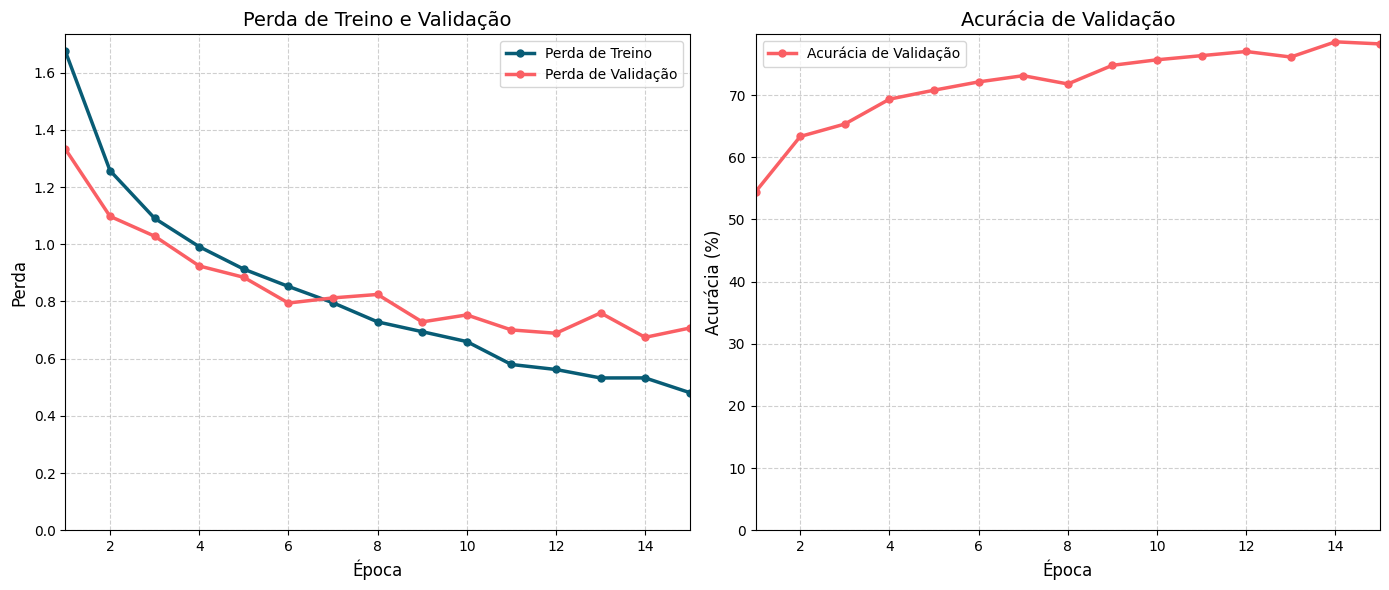

In [15]:
# Inicia o processo de treinamento chamando a função do loop de treino
trained_proto_model, training_metrics_proto = training_loop(
    model=prototype_model, 
    train_loader=train_loader_proto, 
    val_loader=val_loader_proto, 
    loss_function=loss_function, 
    optimizer=optimizer_prototype, 
    num_epochs=15, 
    device=device
)

# Visualiza os gráficos das métricas de treinamento (perda e acurácia)
print("\n--- Gráficos do Treinamento ---\n")
helper_utils_7.plot_training_metrics(training_metrics_proto)

Excelente trabalho! O modelo protótipo está treinado e os resultados parecem muito promissores. Alcançar uma acurácia de validação superior a **75%** no subconjunto de 9 classes é um ótimo resultado e confirma que a sua arquitetura CNN é muito adequada para esta tarefa.

Este protótipo bem-sucedido lhe dá o sinal verde para avançar para a próxima fase: treinar um modelo completo em todas as 15 classes para o borboletário. Mas, antes de fazer isso, é útil realizar uma última verificação qualitativa para ver como o seu modelo "pensa".

### Visualizando as Previsões

Embora os gráficos mostrem o desempenho geral do seu modelo, observar previsões individuais proporciona uma noção mais intuitiva dos seus pontos fortes e fracos. Agora você pode usar uma função auxiliar para ver o seu modelo em ação, visualizando suas previsões em imagens aleatórias do conjunto de validação. Isso mostrará exemplos concretos de onde ele acerta e onde pode estar cometendo erros.

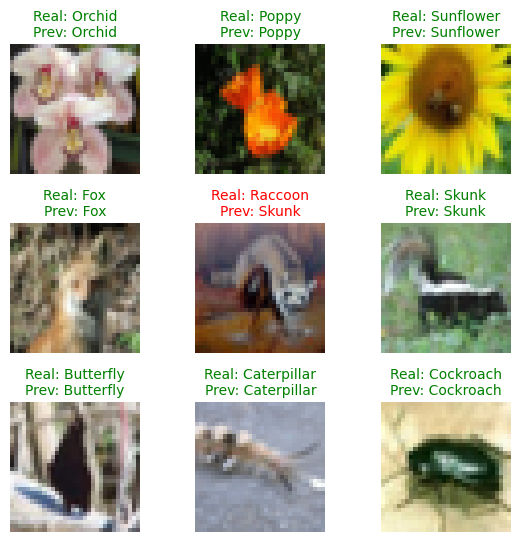

In [16]:
# Visualiza as previsões do modelo em uma amostra de imagens de validação
# Exibe uma grade de 3x3 comparando as imagens com seus rótulos reais e previstos pelo modelo treinado
helper_utils_7.visualise_predictions(
    model=trained_proto_model, 
    data_loader=val_loader_proto, 
    device=device, 
    grid=(3, 3)
)

## Aumentando a Escala: Treinando o Modelo Completo

O protótipo foi um sucesso! Agora é hora de treinar o modelo final para o aplicativo do borboletário. Você repetirá os mesmos passos de antes, mas desta vez usando o conjunto de dados completo e mais desafiador de **15 classes**.

* Primeiro, crie uma nova lista contendo todas as 15 classes alvo.
* Use a função auxiliar `load_cifar100_subset` novamente para criar os novos conjuntos de dados de treinamento e validação com base nesta lista completa.

In [17]:
# Define a lista completa de classes que serão utilizadas (classes-alvo)
all_target_classes = [
    # Flores
    'orchid', 'poppy', 'rose', 'sunflower', 'tulip',
    # Mamíferos
    'fox', 'porcupine', 'possum', 'raccoon', 'skunk',
    # Insetos
    'bee', 'beetle', 'butterfly', 'caterpillar', 'cockroach'
]

# Carrega os conjuntos de dados (datasets) completos de treino e validação filtrados pelas classes definidas
train_dataset, val_dataset = helper_utils_7.load_cifar100_subset(all_target_classes, train_transform, val_transform)

Dataset encontrado em './cifar_100'. Carregando dos arquivos locais.
Dataset carregado com sucesso.

Filtrando para 15 classes...
Filtragem concluída. Retornando os datasets de treino e validação.


* Encapsule seus novos conjuntos de dados de 15 classes em instâncias de `DataLoader`, utilizando o mesmo `batch_size=64`.

In [18]:
# Cria um carregador de dados (DataLoader) para o conjunto de treino, com o embaralhamento (shuffle) ativado
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Cria um carregador de dados (DataLoader) para o conjunto de validação, sem embaralhamento
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

* Exiba uma amostra de imagens do seu novo conjunto de treinamento de 15 classes para confirmar que ele foi carregado corretamente.

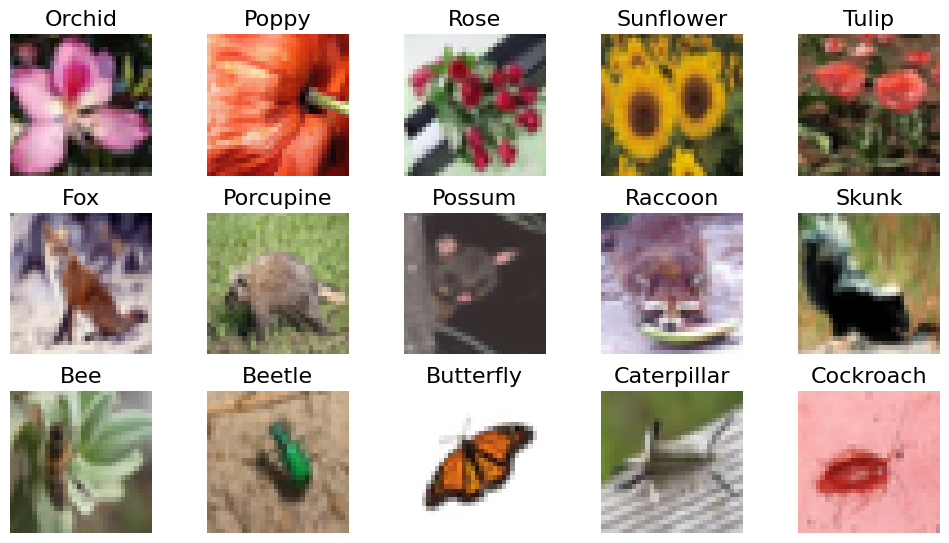

In [19]:
# Visualiza uma grade de 3x5 com imagens aleatórias do conjunto de treino completo
# A função seleciona e exibe amostras do dataset para verificação visual das 15 classes
helper_utils_7.visualise_images(train_dataset, grid=(3, 5))

* Crie uma nova instância do seu modelo `SimpleCNN`, desta vez configurada para todas as **15 classes**.

In [20]:
# Obtém o número total de classes do conjunto de dados completo (agora com as 15 classes)
num_classes = len(train_dataset.classes)

# Instancia o modelo completo com a arquitetura definida na classe SimpleCNN
model = SimpleCNN(num_classes)

# Imprime a arquitetura do modelo (note que a camada final agora possui 15 classes de saída)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=15, bias=True)
)


* Crie um novo otimizador `Adam` para o seu modelo completo de 15 classes.

In [21]:
# Otimizador para o modelo completo
# Utiliza o algoritmo Adam para atualizar todos os parâmetros do modelo com uma taxa de aprendizado (learning rate) de 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

* Chame o `training_loop` para treinar o seu modelo de 15 classes por `25 epochs`. Em seguida, a função `plot_training_metrics` visualizará imediatamente as curvas de perda e acurácia desta rodada final de treinamento.

--- Treinamento Iniciado ---
Época [1/25], Perda Treino: 2.1726, Perda Val: 1.8049, Acurácia Val: 37.67%
Época [2/25], Perda Treino: 1.7751, Perda Val: 1.5465, Acurácia Val: 47.53%
Época [3/25], Perda Treino: 1.5903, Perda Val: 1.4721, Acurácia Val: 50.00%
Época [4/25], Perda Treino: 1.4896, Perda Val: 1.3910, Acurácia Val: 55.60%
Época [5/25], Perda Treino: 1.3938, Perda Val: 1.2927, Acurácia Val: 54.53%
Época [6/25], Perda Treino: 1.3119, Perda Val: 1.2944, Acurácia Val: 57.20%
Época [7/25], Perda Treino: 1.2447, Perda Val: 1.2156, Acurácia Val: 58.67%
Época [8/25], Perda Treino: 1.1791, Perda Val: 1.1645, Acurácia Val: 60.20%
Época [9/25], Perda Treino: 1.1256, Perda Val: 1.1188, Acurácia Val: 62.13%
Época [10/25], Perda Treino: 1.0764, Perda Val: 1.1602, Acurácia Val: 61.33%
Época [11/25], Perda Treino: 1.0264, Perda Val: 1.0948, Acurácia Val: 63.07%
Época [12/25], Perda Treino: 0.9703, Perda Val: 1.0891, Acurácia Val: 62.87%
Época [13/25], Perda Treino: 0.9334, Perda Val: 1.0236, 

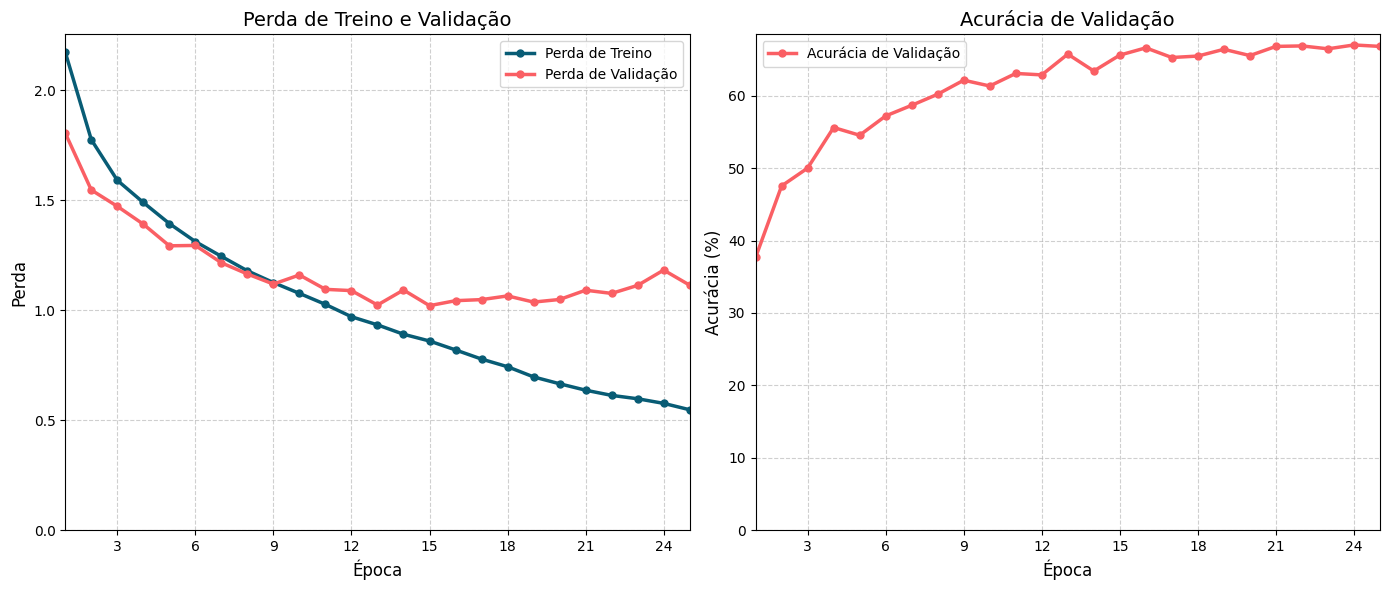

In [22]:
# Inicia o processo de treinamento do modelo completo para todas as 15 classes
trained_model, training_metrics = training_loop(
    model=model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    loss_function=loss_function, 
    optimizer=optimizer, 
    num_epochs=25, 
    device=device
)

# Visualiza os gráficos das métricas de treinamento para o modelo completo
print("\n--- Gráficos do Treinamento ---\n")
helper_utils_7.plot_training_metrics(training_metrics)

Após treinar o modelo completo, você pode analisar os resultados. Mas espere, algo não está certo aqui. O seu modelo protótipo treinou com sucesso, mostrando uma melhoria constante. No entanto, o desempenho no conjunto de dados completo de 15 classes parece ter atingido um limite. O que aconteceu?

Um olhar atento aos gráficos revela o problema. Enquanto a **Perda de Treinamento** (*Training Loss*) diminui de forma consistente, a **Perda de Validação** (*Validation Loss*) cai por um tempo e, em seguida, começa a subir e a flutuar. Ao mesmo tempo, a **Acurácia de Validação** (*Validation Accuracy*) trava, atingindo um platô sem fazer progresso significativo adicional. Este é um caso clássico de **overfitting** (sobreajuste).

O *overfitting* ocorre quando um modelo aprende os dados de treinamento *bem até demais*, incluindo seus ruídos e peculiaridades específicas, em vez de aprender os padrões gerais subjacentes que o ajudariam a ter um bom desempenho em dados novos e não vistos. A lacuna cada vez maior entre a sua perda de treinamento e a de validação é um sinal claro de que o seu modelo está memorizando o conjunto de treinamento em vez de aprender a **generalizar**.

Você pode se perguntar por que isso aconteceu agora e não com o protótipo de 9 classes. O motivo é o aumento significativo na **complexidade da tarefa**. Distinguir entre 15 classes é muito mais difícil do que 9, exigindo que o modelo aprenda características mais sutis. Diante desse desafio mais difícil, o seu poderoso modelo CNN encontrou um caminho mais fácil para diminuir a perda de treinamento: ele começou a memorizar os dados de treinamento em vez de aprender a generalizar.

Este problema de *overfitting* apresenta um desafio realista, semelhante ao que você encontraria em um projeto do mundo real. Na tarefa avaliada deste módulo, você enfrentará esse problema fazendo várias atualizações em todo o seu pipeline para ver se consegue melhorar a capacidade de generalização do modelo.

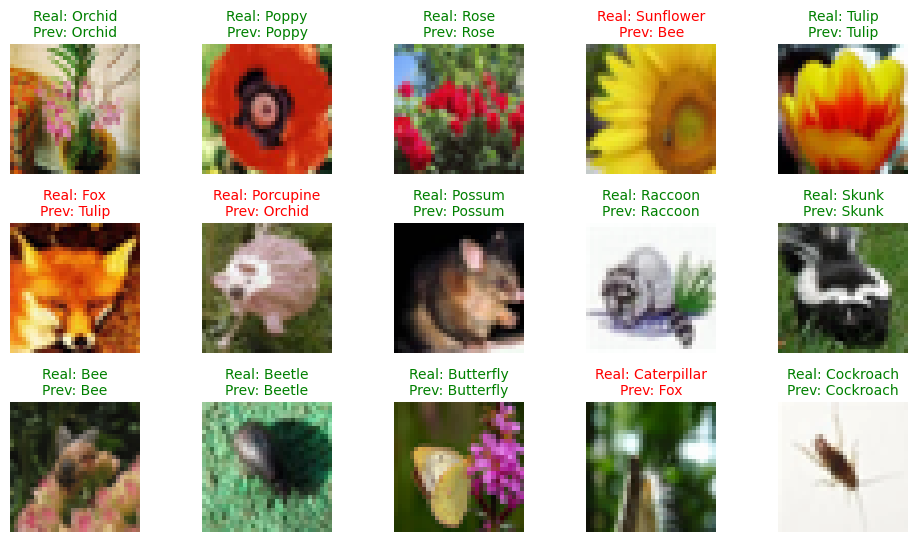

In [23]:
# ### Opcional: Descomente e execute esta célula para ver as previsões feitas pelo modelo completo

helper_utils_7.visualise_predictions(
     model=trained_model, 
     data_loader=val_loader, 
     device=device, 
     grid=(3, 5)
 )

## Conclusão

Parabéns por concluir o laboratório! Você navegou com sucesso por todo o pipeline de aprendizado de máquina, desde a preparação de dados até a construção, treinamento e análise da sua própria Rede Neural Convolucional.

Você colocou a teoria em prática construindo uma arquitetura CNN capaz de aprender padrões visuais complexos. Mais importante ainda, você vivenciou um fluxo de trabalho de desenvolvimento realista e iterativo, criando primeiro um protótipo bem-sucedido e, em seguida, aumentando a escala para um modelo mais complexo. Esse processo o levou a encontrar e diagnosticar o *overfitting* (sobreajuste), um desafio fundamental que todo profissional de aprendizado de máquina deve aprender a resolver.

As habilidades que você desenvolveu aqui o prepararam para o próximo passo. Você identificou o problema e, na tarefa avaliada, terá a chance de resolvê-lo. Bom trabalho!